# Mathematical foundations of kernel methods

## Block 1 (45 min) — Theory  

### The Kernel Trick: The Basic Idea
        
Many learning problems are nonlinear in the input space $\mathcal X \subset \mathbb{R}^d$.
Linear models in this space may therefore fail to capture the structure of the data.
The key idea of kernel methods is to map data into a (possibly infinite-dimensional)
Hilbert space $\mathcal{H}$ via a feature map
$$
\Phi : \mathcal X \to \mathcal{H},
$$
where linear methods can be applied.

<div style="text-align: center;">
<img src="./kernel_trick.jpeg" width="450" height="200">
</div>

The intuition is that a transformation to a higher-dimensional space can make
complex nonlinear patterns linearly separable.
In other words, a linear decision boundary in the feature space may correspond
to a nonlinear boundary in the original input space.

A linear model in feature space has the form
$$
f(x) = \langle w, \Phi(x) \rangle_{\mathcal H},
$$
which corresponds to a nonlinear function in the original input space.
Kernel methods avoid explicit construction of $\Phi$ by working directly with inner
products
$$
k(x,y) := \langle \Phi(x), \Phi(y) \rangle_{\mathcal H}.
$$

This idea is known as the kernel trick: many algorithms depend on the data
only through inner products, so replacing these inner products with a kernel
function allows the algorithm to operate implicitly in the high-dimensional
feature space without ever computing the mapping $\Phi$ explicitly.

---

[Kilian Q. Weinberger](https://www.cs.cornell.edu/~kilian/) gives engaging lectures on machine learning at Cornell University.  
The lecture notes are available at

https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote13.html

and the lectures themselves can also be freely accessed on YouTube.  
The lecture on the kernel trick is accompanied by particularly clear and visually appealing illustrations that help build intuition about kernel methods.

These lectures approach the topic mainly from a practical machine learning perspective, and therefore provide a useful complement to the present course. The aim of this course—*Mathematical Foundations of AI*, as the name suggests—is rather to understand the mathematical constructions, theorems, and phenomena that appear in AI algorithms.

---

### The Mathematics of the Kernel Trick

Let $\mathcal H$ be a Hilbert space and let $f : \mathcal H \to \mathbb{R}$ be a linear mapping (called a **linear functional**).

The functional $f$ is called **bounded** if the image of the unit ball is bounded; equivalently, if there exists a constant $C \ge 0$ such that
$$
|f(x)| \le C\,\|x\| \qquad \text{for all } x \in \mathcal H .
$$

The smallest such constant is called the **operator norm** of $f$ and is given by
$$
\|f\| := \sup_{\|x\|\le 1} |f(x)|.
$$

**Proposition.**  
For a linear functional $f:\mathcal H \to \mathbb{R}$ the following properties are equivalent:

1. $f$ has the representation
  $$
  f(x)=\langle p,x\rangle
  $$
  for some fixed vector $p\in\mathcal H$ (Riesz representation theorem),

2. $f$ is bounded,

3. $f$ is Lipschitz; that is, there exists $L>0$ such that
  $$
  |f(x)-f(y)| \le L\|x-y\|
  $$

4. $f$ is continuous everywhere,

5. $f$ is continuous at some point $x_0\in\mathcal H$.
   

**Definition (RKHS):**  Let $\mathcal{H}$ be a Hilbert space of real-valued functions on a set $\mathcal{X}$.
The space $\mathcal{H}$ is called a **reproducing kernel Hilbert space** if, for every $x\in\mathcal{X}$, the evaluation functional
$$
\delta_x : \mathcal{H} \to \mathbb{R}, \qquad \delta_x(f)=f(x),
$$
is continuous.

**Remark:** If $\mathcal H$ is finite-dimensional, that is, $\mathcal H=\mathbb{R}^n$, then every linear functional is continuous. In particular, the evaluation functionals are continuous. Consequently, every finite-dimensional Hilbert space is a reproducing kernel Hilbert space.

**Example:** The space $L^2[0,1]$ is **not** a reproducing kernel Hilbert space. There are two reasons for this.  

First, the elements of $L^2[0,1]$ are not really functions, but equivalence classes of functions: if two functions $f$ and $g$ differ only on a set of measure zero (for example, at finitely many points), they represent the same element of $L^2[0,1]$. Therefore, the point evaluation functional
$$
\delta_x(f) = f(x)
$$
is not well-defined on $L^2[0,1]$.  

Second, even if we ignore the first issue, evaluation can fail to be continuous. For instance, consider the sequence

$$
f_n(t) = \sqrt{n}\, e^{nt}, \quad n \in \mathbb{N}.
$$

In $L^2[0,1]$, this sequence is bounded, but

$$
\delta_0(f_n) = f_n(0) = \sqrt{n} \to \infty \quad \text{as } n \to \infty.
$$

Hence, the evaluation functional at $0$ is unbounded, and $L^2[0,1]$ cannot be an RKHS.

#### Reproducing Kernel

By the Riesz representation theorem, for each $x \in \mathcal X$ there exists a unique element $k_x \in \mathcal H$ such that
$$
f(x) = \langle f, k_x \rangle_{\mathcal H}, \quad \forall f \in \mathcal H.
$$

The function
$$
k : \mathcal X \times \mathcal X \to \mathbb{R}, \qquad k(x,y) := k_x(y),
$$
is called the **reproducing kernel** of $\mathcal H$.

**Properties:**

1. **Symmetry:**  
   $$
   k(x,y) = k(y,x), \quad \forall x, y \in \mathcal X.
   $$

2. **Positive definiteness:** For any finite set of points $x_1, \dots, x_n \in \mathcal X$ and any real coefficients $c_1, \dots, c_n$,
   $$
   \sum_{i,j=1}^n c_i c_j k(x_i, x_j) \ge 0.
   $$
   In other words, $K=[K_{ij}]$, where $K_{ij}=k(x_i, x_j)$ is a positive definite matrix.

*Proof:*

1. **Symmetry:**  
$$
k(x, y) = k_x(y) = \langle k_y, k_x \rangle_{\mathcal H} = \langle k_x, k_y \rangle_{\mathcal H} = k_y(x) = k(y,x).
$$

2. **Positive definiteness:**  
Let 
$$
x = \sum_{i=1}^n c_i k_{x_i} \in \mathcal H.
$$  
Then its squared norm is
$$
\|x\|^2 = \left\langle \sum_{i=1}^n c_i k_{x_i}, \sum_{j=1}^n c_j k_{x_j} \right\rangle
= \sum_{i,j=1}^n c_i c_j \langle k_{x_i}, k_{x_j} \rangle
= \sum_{i,j=1}^n c_i c_j k(x_i, x_j) \ge 0.
$$
Hence, $k$ is positive definite.

**Theorem (Moore–Aronszajn):** Suppose $K: \mathcal{X}\times \mathcal{X}\to \mathbb{R}$ is a symmetric, positive definite kernel function on a set $\mathcal{X}$. Then there exists a unique Hilbert space of functions on $\mathcal{X}$ for which $K$ serves as the reproducing kernel.

*Sketch of the proof:* The proof is based on the following construction.  
First, we define a function space $\mathcal{H}_0$ consisting of functions of the form
$$
f(x)=\sum_{i=1}^n c_i K(x_i, x), \qquad x\in\mathcal{X},
$$
where $x_1,\ldots,x_n$ is an arbitrary finite collection of points in $\mathcal{X}$ and  
$c_1,\ldots,c_n$ are real numbers.

For two elements $f_1,f_2\in\mathcal{H}_0$, written as
$$
f_1(x)=\sum_{i=1}^n c_i^{(1)} K(x_i^{(1)},x), 
\qquad
f_2(x)=\sum_{j=1}^m c_j^{(2)} K(x_j^{(2)},x),
$$
we define their inner product by
$$
\langle f_1,f_2\rangle
:=
\sum_{i=1}^n \sum_{j=1}^m 
c_i^{(1)} c_j^{(2)} K(x_i^{(1)},x_j^{(2)}).
$$

- It can be shown that this operation indeed defines an inner product on $\mathcal{H}_0$.
- Taking the completion of $\mathcal{H}_0$ with respect to this inner product yields a Hilbert space $\mathcal{H}$ whose elements are functions $\mathcal{X}\to\mathbb{R}$.
- One can then verify that $\mathcal{H}$ is a reproducing kernel Hilbert space with reproducing kernel $K$.

---

#### RKHSs and Feature Maps

Assume that $\mathcal{X}$ is an abstract set and $F$ is a Hilbert space (the *feature space*). Let $\Phi:\mathcal{X}\to F$ be a mapping, called a *feature map*. Define a function $K:\mathcal{X}\times\mathcal{X}\to\mathbb{R}$ by
$$
K(x,y) = \langle \Phi(x), \Phi(y)\rangle_F,
$$
where $\langle\cdot,\cdot\rangle_F$ denotes the inner product in $F$.

It is straightforward to verify that $K$ is symmetric and positive definite. Therefore, by the Moore–Aronszajn theorem, there exists a reproducing kernel Hilbert space $\mathcal{H}$ whose reproducing kernel is precisely $K$.

Conversely, suppose that $\mathcal{H}$ is a reproducing kernel Hilbert space on $\mathcal{X}$ with kernel $K:\mathcal{X}\times\mathcal{X}\to\mathbb{R}$. Then the mapping
$$
\Phi:\mathcal{X}\to\mathcal{H}, 
\qquad
x \mapsto \Phi(x):=K(x,\cdot)
$$
defines a feature map for which
$$
K(x,y)=\langle \Phi(x), \Phi(y)\rangle_{\mathcal{H}}, 
\qquad x,y\in\mathcal{X}.
$$

#### Examples of RKHS and Kernels

**1. Linear Kernel**
$$
k(x,y) = x^\top y, \quad x,y \in \mathbb{R}^d
$$

- **RKHS:** $\mathcal H = \mathbb{R}^d$  
- **Evaluation functional:** $\delta_x(f) = f(x) = w^\top x$ for linear $f(x) = w^\top x$  
- **Dimension:** Finite, exactly $d$  
- **Properties:**  
  - Suitable for linear decision boundaries  
  - All linear functionals are continuous; evaluation functionals are trivially reproduced: $k_x = x$  

**Note:** Using the linear kernel is equivalent to standard linear modeling (e.g., linear regression, linear SVM).

**2. Polynomial Kernel**
$$
k(x,y) = (1 + x^\top y)^p, \quad p \in \mathbb{N}
$$

- **RKHS:** Space of polynomials of degree at most $p$ in the input features  
  - Example: $d=2, p=2$ → $\mathcal{H}$ contains $1, x_1, x_2, x_1^2, x_1 x_2, x_2^2$  
- **Dimension:** Finite, grows with $p$ and $d$  
- **Properties:**  
  - Can model nonlinear decision boundaries linearly in the higher-dimensional feature space  
  - Evaluation functionals are used implicitly via the kernel trick: $f(x) = \sum_i \alpha_i k(x_i, x)$  

**Note:** Commonly used in SVMs for nonlinear patterns. The parameter $p$ controls complexity and flexibility.

**3. Gaussian (RBF) Kernel**
$$
k(x,y) = \exp\left(-\frac{\|x-y\|^2}{2\sigma^2}\right)
$$

- **RKHS:** Infinite-dimensional; elements are very smooth, essentially analytic functions  
- **Dimension:** Infinite; **universal approximator**—any continuous function can be approximated arbitrarily well with appropriate linear combination of RBFs  
- **Properties:**  
  - Highly flexible; can model complex, curved decision boundaries  
  - Evaluation functionals are reproduced implicitly via the kernel trick  
  - Parameter $\sigma$ controls the smoothness and locality: smaller $\sigma$ → more local, larger $\sigma$ → more global influence  

**Note:** The most widely used kernel in SVMs and Gaussian processes due to its flexibility and universality.

---

#### Emprirical loss minimization in RKHSs

In machine learning, a common task is the following: 
- We are given a training sample
$(x_i,y_i)$, $i=1,\ldots,n$, where $x_i\in\mathcal{X}$ and $y_i\in\mathbb{R}$, together with a loss function  
$L:\mathcal{X}\times\mathbb{R}\times\mathbb{R}\to\mathbb{R}$ and a regularization functional $G:\mathcal{F}(\mathcal{X})\to\mathbb{R}$.

- The goal is to minimize the (generally nonlinear) functional
$$
f \mapsto 
L\big((x_1,y_1,f(x_1)),\ldots,(x_n,y_n,f(x_n))\big) + G(f).
$$

Problems of this type arise naturally in statistical learning. Suppose that $X$ is an $\mathcal{X}$-valued random variable and $Y$ is a real-valued random variable. We would like to find a function $f:\mathcal{X}\to\mathbb{R}$ that minimizes the expected loss
$$
\mathbb{E}[\,l(Y,f(X))\,],
$$
where $l:\mathbb{R}\times\mathbb{R}\to\mathbb{R}$ is a prescribed loss function.

Since the joint distribution of $X$ and $Y$ is unknown and we only observe the training sample $(x_i,y_i)$, $i=1,\ldots,n$, a natural approach is to minimize the empirical loss
$$
f \mapsto L\big((x_1,y_1,f(x_1)),\ldots,(x_n,y_n,f(x_n))\big):=\frac{1}{n}\sum_{i=1}^n l(y_i,f(x_i)).
$$

**Theorem (Representer theorem).**  
Suppose that $\mathcal{H}$ is a reproducing kernel Hilbert space on $\mathcal{X}$ with kernel $K$, and that the minimizer $f^\ast$ is sought within this space. Assume that the regularization term has the form
$$
G(f)=g(\|f\|^2),
$$
where $g:[0,\infty)\to[0,\infty)$ is a strictly increasing function. Then the minimizer $f^\ast$ (if exists) admits a finite expansion
$$
f^\ast(\cdot)=\sum_{i=1}^n \alpha_i\, K(x_i,\cdot).
$$

*Proof.*  
Using the notation $K_x(\cdot)=K(x,\cdot)$, let
$$
\mathcal{H}_0=\operatorname{Span}\{K_{x_1},\ldots,K_{x_n}\}.
$$
The elements of the subspace $\mathcal{H}_0\subset\mathcal{H}$ are precisely the functions of the form
$$
\sum_{i=1}^n \alpha_i\,K(x_i,\cdot).
$$

From the theory of Hilbert spaces, every $f\in\mathcal{H}$ admits a unique decomposition
$$
f=f_{\mathcal{H}_0}+f_{\mathcal{H}_0^\perp},
$$
where $f_{\mathcal{H}_0}\in\mathcal{H}_0$ and $f_{\mathcal{H}_0^\perp}\in\mathcal{H}_0^\perp$.

**1st key observation.**  
The loss functional $L$ depends only on the function values $f(x_i)$, $i=1,\ldots,n$. Using the reproducing property, we have
$$
f(x_i)=\langle f,K_{x_i}\rangle
      =\langle f_{\mathcal{H}_0},K_{x_i}\rangle
       +\langle f_{\mathcal{H}_0^\perp},K_{x_i}\rangle
      =f_{\mathcal{H}_0}(x_i),
$$
for $i=1,\ldots,n$, since $K_{x_i}\in\mathcal{H}_0$ and therefore  
$\langle f_{\mathcal{H}_0^\perp},K_{x_i}\rangle=0$. Hence the value of the loss $L$ is *not affected* by the component $f_{\mathcal{H}_0^\perp}$.

**2nd key observation.**  
Since
$$
\|f\|^2=\|f_{\mathcal{H}_0}\|^2+\|f_{\mathcal{H}_0^\perp}\|^2
\ge \|f_{\mathcal{H}_0}\|^2,
$$
and $g$ is strictly increasing, we obtain
$$
g(\|f\|^2)\ge g(\|f_{\mathcal{H}_0}\|^2).
$$
Therefore the choice $f_{\mathcal{H}_0^\perp}=0$ minimizes the regularization term.

**Remarks**

- The above form of the Representer theorem was proved by Schölkopf, Herbrich, and Smola.
- The importance of the theorem lies in the fact that it reduces an optimization problem posed in the very large—possibly infinite-dimensional—space $\mathcal{H}$ to an optimization problem in $\mathbb{R}^n$.
- The Representer theorem can be generalized to a somewhat broader class of loss functions; however, it is essential that the regularization term has the form $G(f)=g(\|f\|^2)$ with $g:[0,\infty)\to[0,\infty)$ strictly increasing.

**Take home message:**
> Although $\mathcal{H}$ may be infinite-dimensional, the solution lives in an $n$-dimensional subspace.

## Block 2 (45 min) — Practical Part

### Application: Kernel Ridge Regression

Suppose we consider the regularized nonlinear least squares problem with objective
$$
f \mapsto L(f)=\sum_{k=1}^n (y_k-f(x_k))^2+\lambda\|f\|^2,
$$
where $f$ is an element of a reproducing kernel Hilbert space over $\mathcal{X}$.

By the Representer theorem, the minimizer can be written in the form
$$
f=\sum_{k=1}^n w_k K_{x_k},
$$
for some coefficients $w_1,\ldots,w_n$. Substituting this representation into the objective function yields
$$
L(f)=\sum_{i=1}^n\left(y_i-\sum_{j=1}^n w_j K_{x_j}(x_i)\right)^2
+\lambda\sum_{i,j=1}^n w_i w_j K(x_i,x_j).
$$

Observe that this expression can be written in matrix form as
$$
L(f)=\|\mathbf{y}-\mathbf{K}\mathbf{w}\|^2+\lambda\,\mathbf{w}^\top \mathbf{K}\mathbf{w},
$$
where
- $\mathbf{y}=[y_1,\ldots,y_n]^\top$,
- $\mathbf{w}=[w_1,\ldots,w_n]^\top$,
- $\mathbf{K}_{i,j}=K(x_i,x_j)$, $i,j=1,\ldots,n$,

and $\mathbf{K}$ is the so-called **kernel matrix**.

This is an ordinary regularized least squares problem, whose solution is known in closed form:
$$
\mathbf{w}=(\mathbf{K}^\top\mathbf{K}+\lambda \mathbf{K})^{-1}\mathbf{K}^\top\mathbf{y}.
$$

**Take-home message**

> No explicit feature map $\Phi$ is required; it is sufficient to know the kernel matrix $\mathbf{K}$.  
> This idea is known as the **kernel trick**.

## Block 3 (45 min) — Programming

### **Exercise 1: Kernel Gram Matrix**

**Goal:** Understand how the kernel (Gram) matrix is constructed and verify its positive definiteness.

**Description:**  
- Generate `n` random points in $\mathbb{R}^2$.  
- Define three kernels: Linear, Polynomial (degree 2), and Gaussian (RBF, $\sigma=1$).  
- Compute the Gram matrix $K_{ij} = k(x_i, x_j)$ for each kernel.  
- Check whether the matrix is positive definite by examining its eigenvalues.  
- Optional: Visualize each Gram matrix using a heatmap

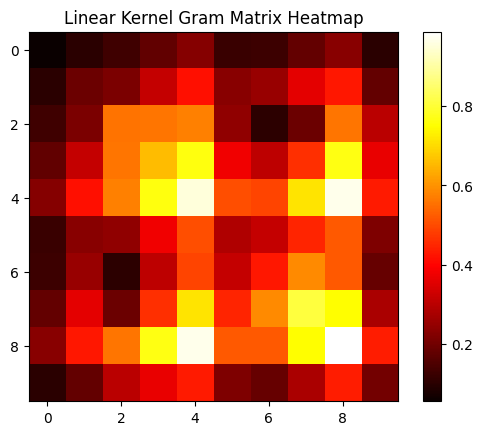

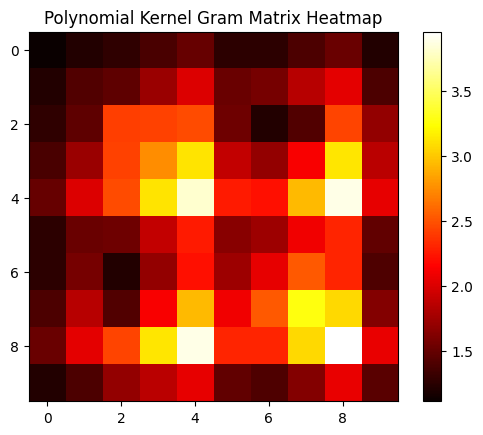

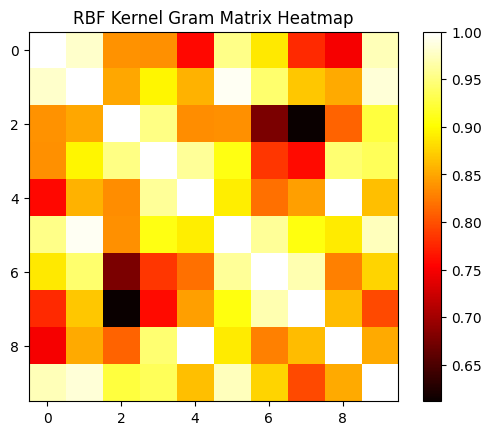

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random points in R^2
n = 10
X = np.random.rand(n, 2)

# Define kernels
def linear_kernel(x, y):
    return x @ y

def poly_kernel(x, y, p=2):
    return (1 + x @ y)**p

def rbf_kernel(x, y, sigma=1.0):
    return np.exp(-np.linalg.norm(x - y)**2 / (2 * sigma**2))

kernels = {'Linear': linear_kernel, 'Polynomial': poly_kernel, 'RBF': rbf_kernel}

for name, k in kernels.items():
    K = np.array([[k(xi, xj) for xj in X] for xi in X])
    # print(f"{name} kernel Gram matrix:\n", K)
    eigvals = np.linalg.eigvalsh(K)
    # print(f"Eigenvalues: {eigvals}\nPositive definite? {np.all(eigvals > 0)}\n")
    plt.figure()
    plt.title(f"{name} Kernel Gram Matrix Heatmap")
    plt.imshow(K, cmap='hot', interpolation='nearest')
    plt.colorbar()
    plt.show()

### Exercise 2: Implicit High-Dimensional Mapping (Kernel Trick)

**Goal:** Demonstrate the kernel trick by making a nonlinearly separable dataset linearly separable in a higher-dimensional RKHS.

**Description:**  
- Generate 1D data $x_i \sim [-1,1]$ with labels $y_i = \text{sign}(x_i^2 - 0.5)$ (nonlinear separation).  
- Train a linear SVM using a polynomial kernel (degree 2).  
- Visualize how the data becomes linearly separable in the feature space using the decision function.

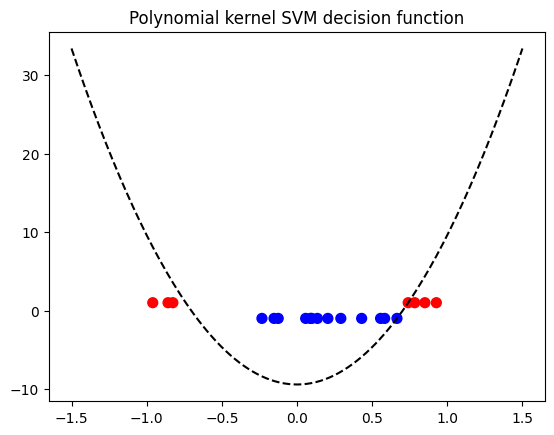

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Generate 1D nonlinearly separable data
np.random.seed(0)
X = np.random.uniform(-1, 1, (20, 1))
y = np.sign(X**2 - 0.5).ravel()

# Train SVM with polynomial kernel (degree=2)
clf_poly = SVC(kernel='poly', degree=2, C=1e5)
clf_poly.fit(X, y)

# Plot decision function
X_plot = np.linspace(-1.5, 1.5, 200).reshape(-1,1)
y_plot = clf_poly.decision_function(X_plot)
plt.scatter(X, y, c=y, cmap='bwr', s=50)
plt.plot(X_plot, y_plot, 'k--')
plt.title("Polynomial kernel SVM decision function")
plt.show()

### Exercise 3: Function Approximation in RKHS (Kernel Ridge Regression)

**Goal:** Explore how RKHS can be used for smooth function approximation using the reproducing property of kernels.

**Description:**  
- Choose a target function $f(x) = \sin(3x)$ on the interval $[0, 2\pi]$.  
- Sample a small number of training points from the interval.  
- Implement kernel ridge regression using the Gaussian (RBF) kernel:  
  $$
  \hat f(x) = \sum_i \alpha_i k(x_i, x)
  $$  
  where $x_i$ are the training points and $\alpha_i$ are the coefficients to solve for.  
- Solve for $\alpha_i$ and plot both the true function $f(x)$ and the RKHS approximation $\hat f(x)$.  
- Optional: Experiment with the kernel width parameter $\sigma$ to observe effects on underfitting or overfitting.

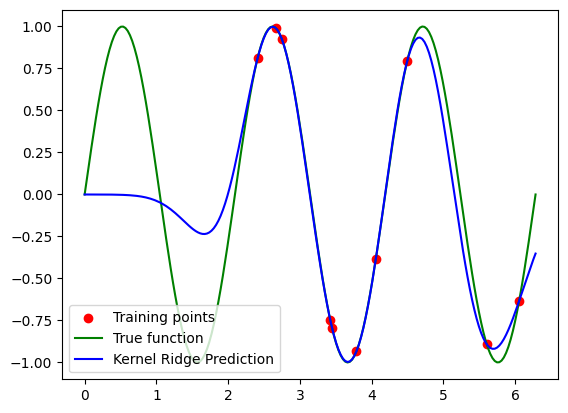

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Target function
f = lambda x: np.sin(3*x)

# Sample points
np.random.seed(0)
X_train = np.random.uniform(0, 2*np.pi, 10)[:, None]
y_train = f(X_train).ravel()

# Gaussian kernel
def rbf_kernel_matrix(X1, X2, sigma=0.5):
    return np.exp(-np.sum((X1[:,None,:] - X2[None,:,:])**2, axis=2)/(2*sigma**2))

# Kernel Ridge Regression
sigma = 0.5
lambda_reg = 1e-5
K = rbf_kernel_matrix(X_train, X_train, sigma)
alpha = np.linalg.solve(K + lambda_reg*np.eye(len(X_train)), y_train)

# Prediction
X_test = np.linspace(0, 2*np.pi, 200)[:, None]
K_test = rbf_kernel_matrix(X_test, X_train, sigma)
y_pred = K_test @ alpha

# Plot
plt.scatter(X_train, y_train, color='red', label='Training points')
plt.plot(X_test, np.sin(3*X_test), 'g', label='True function')
plt.plot(X_test, y_pred, 'b', label='Kernel Ridge Prediction')
plt.legend()
plt.show()